# Almond Trees Getting Insomnia: Winter Chill Accumulation and Almond Yield in Fresno County, California

**Project Sprint One, Milestone 2**

**Author of this pass:** James Sneddon (DS2)
**Team:** James Sneddon and three teammates (names withheld here for privacy)
**Course:** DSC450 Applied Data Science, Bellevue University
**Date:** July 2026

**Purpose of this notebook.** A teammate built the first pass covering acquisition, cleaning, and an initial model. On this pass I refine the feature and target logic, correct the target to yield per bearing acre, engineer a real chill accumulation metric, build the acreage versus yield relational figure that is my signature deliverable, finalize the modeling and metrics, and add the write-up markdown. The research question is whether accumulated winter chill tracks almond yield in Fresno County, and whether chill hours predict yield better than a plain winter average temperature.

## Read me first: how this notebook resolves its data

This notebook expects four raw files in its folder:

- `raw_data_USDA.csv` from USDA NASS Quick Stats (Fresno County almonds)
- `raw_temp_part1.csv`, `raw_temp_part2.csv`, `raw_temp_part3.csv` from NOAA Local Climatological Data (Fresno station, split into three pulls because NOAA caps a pull at ten years)

The loader prefers those real files. If any of them is missing it falls back to a clearly labeled synthetic stand in written into a `synthetic/` subfolder, so the notebook still runs top to bottom and produces every table and figure. When synthetic data is in use, a banner prints and every headline number is tagged so nobody mistakes placeholder output for the real result.

To use the real data, drop the four files listed above into this folder and run all cells again. The real files automatically take priority and the synthetic path is skipped. Nothing else needs to change.

In [1]:
# Standard imports for the whole notebook
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Colorblind-safe accents used across the figures
C_ACRE = "#0072B2"   # blue, planting/capacity trend
C_YIELD = "#D55E00"  # vermillion, the climate-sensitive component
C_CHILL = "#009E73"  # green, chill accumulation
C_FIT = "#333333"

# Where files live. The notebook folder is the working directory.
DATA_DIR = os.getcwd()
SYN_DIR = os.path.join(DATA_DIR, "synthetic")

REQUIRED = {
    "usda": "raw_data_USDA.csv",
    "t1": "raw_temp_part1.csv",
    "t2": "raw_temp_part2.csv",
    "t3": "raw_temp_part3.csv",
}
print("Working directory:", DATA_DIR)

Working directory: .


In [2]:
# ----------------------------------------------------------------------
# Data resolution. Prefer real files in the notebook folder. If any is
# missing, generate a schema-faithful synthetic stand in under synthetic/.
# The synthetic world is internally consistent: chill/freeze/fog are computed
# from the same hourly series that drives yield, so the pipeline downstream
# behaves exactly as it would on real data.
# ----------------------------------------------------------------------

def _build_synthetic(seed=450):
    rng = np.random.default_rng(seed)
    os.makedirs(SYN_DIR, exist_ok=True)

    # Harvest years modeled. Contiguous here so the multiple regression has
    # real degrees of freedom for demonstration. The real USDA pull may cover
    # fewer or non contiguous years; the code adapts to whatever it receives.
    years = list(range(2003, 2023))  # 2003..2022

    usda_rows = []
    noaa_rows = []

    for Y in years:
        # Latent winter warmth drifts up over the two decades (climate signal).
        warming = (Y - 2003) * 0.06
        winter_mean = 46.5 + warming + rng.normal(0, 1.4)

        # Dormancy window: Nov 1 (Y-1) through Feb 28 (Y).
        start = pd.Timestamp(year=Y - 1, month=11, day=1)
        end = pd.Timestamp(year=Y, month=2, day=28) + pd.Timedelta(days=1)
        hours = pd.date_range(start, end, freq="h", inclusive="left")

        n = len(hours)
        day_of_winter = (hours - start).total_seconds() / 86400.0
        hour_of_day = hours.hour.to_numpy()

        seasonal = -4.0 * np.cos(2 * np.pi * day_of_winter / 120.0)
        diurnal = -8.5 * np.cos(2 * np.pi * (hour_of_day - 4) / 24.0)
        noise = rng.normal(0, 2.4, n)
        # light autocorrelation so hours are not independent white noise
        for i in range(1, n):
            noise[i] = 0.55 * noise[i - 1] + 0.45 * noise[i]
        temp = winter_mean + seasonal + diurnal + noise

        # Realized chill/freeze from the actual hourly series
        chill = int(np.sum((temp >= 32) & (temp <= 45)))
        freeze = int(np.sum(temp <= 32))

        # Fog is more likely on cold calm nights; correlates mildly with chill
        cold = temp < 41
        night = (hour_of_day <= 8) | (hour_of_day >= 22)
        fog_p = np.clip(0.03 + 0.22 * cold + 0.10 * night, 0, 0.6)
        is_fog = rng.random(n) < fog_p
        pw = np.where(is_fog,
                      rng.choice(["FG", "BR", "FG+"], size=n, p=[0.6, 0.3, 0.1]),
                      rng.choice(["", "HZ", ""], size=n, p=[0.85, 0.05, 0.10]))

        # Present temp as strings; inject a few messy LCD style values
        temp_str = np.array(["%.0f" % t for t in temp], dtype=object)
        mask_s = rng.random(n) < 0.02      # trailing 's' suspect flag
        temp_str[mask_s] = np.char.add(temp_str[mask_s].astype(str), "s")
        mask_blank = rng.random(n) < 0.01  # missing reading
        temp_str[mask_blank] = ""

        for ts, tstr, w in zip(hours, temp_str, pw):
            noaa_rows.append({
                "STATION": "72389093193",
                "DATE": ts.strftime("%Y-%m-%dT%H:%M:%S"),
                "REPORT_TYPE": "FM-15",
                "HourlyDryBulbTemperature": tstr,
                "HourlyPresentWeatherType": w,
            })

        # USDA side: bearing acres rise steadily (planting/maturation trend).
        acres = 60000 + (Y - 2003) * 5400 + rng.normal(0, 2500)
        acres = float(max(acres, 1000))
        # Yield driven by chill (positive) and freeze (mild negative) plus noise
        yield_lb = 1500 + 1.05 * chill - 0.6 * freeze + rng.normal(0, 90)
        yield_lb = float(max(yield_lb, 200))
        production = int(round(acres * yield_lb))

        common = dict(Program="SURVEY", Period="YEAR", Week_Ending="",
                      Geo_Level="COUNTY", State="CALIFORNIA", State_ANSI="06",
                      County="FRESNO", County_ANSI="019", Commodity="ALMONDS",
                      Domain="TOTAL", Domain_Category="NOT SPECIFIED")
        usda_rows.append({**common, "Year": Y,
                          "Data Item": "ALMONDS - ACRES BEARING",
                          "Value": "{:,}".format(int(round(acres)))})
        usda_rows.append({**common, "Year": Y,
                          "Data Item": "ALMONDS - PRODUCTION, MEASURED IN LB",
                          "Value": "{:,}".format(production)})

    usda = pd.DataFrame(usda_rows)
    usda.to_csv(os.path.join(SYN_DIR, REQUIRED["usda"]), index=False)

    noaa = pd.DataFrame(noaa_rows)
    # Split into three files by row position to mimic three NOAA pulls, and
    # duplicate a few boundary rows so the de-dupe step has something to remove.
    m = len(noaa)
    bounds = [0, m // 3, 2 * m // 3, m]
    thirds = [noaa.iloc[bounds[i]:bounds[i + 1]].reset_index(drop=True)
              for i in range(3)]
    parts = []
    for j, chunk in enumerate(thirds):
        chunk = chunk.copy()
        if j > 0:
            overlap = thirds[j - 1].tail(6)
            chunk = pd.concat([overlap, chunk], ignore_index=True)
        parts.append(chunk)
    for key, part in zip(["t1", "t2", "t3"], parts):
        part.to_csv(os.path.join(SYN_DIR, REQUIRED[key]), index=False)

    return years


def resolve_sources():
    """Return (paths, using_synthetic). Real files win per file if present."""
    real = {k: os.path.join(DATA_DIR, v) for k, v in REQUIRED.items()}
    missing = [k for k, p in real.items() if not os.path.exists(p)]
    if not missing:
        return real, False
    # Any missing -> use synthetic for the whole set for consistency
    if not all(os.path.exists(os.path.join(SYN_DIR, v)) for v in REQUIRED.values()):
        _build_synthetic()
    syn = {k: os.path.join(SYN_DIR, v) for k, v in REQUIRED.items()}
    return syn, True


PATHS, USING_SYNTHETIC = resolve_sources()
TAG = "[SYNTHETIC PLACEHOLDER] " if USING_SYNTHETIC else ""

In [3]:
# Loud, unmissable banner about which data is active
bar = "=" * 74
if USING_SYNTHETIC:
    print(bar)
    print("  SYNTHETIC PLACEHOLDER DATA IS IN USE")
    print(bar)
    print("  The real raw files were not found in this folder, so the notebook")
    print("  generated a labeled synthetic stand in under ./synthetic/ so every")
    print("  cell runs and every figure renders.")
    print()
    print("  These numbers are NOT the real USDA/NOAA result. Do not paste them")
    print("  into the paper. Drop the four real files into this folder and re-run:")
    for v in REQUIRED.values():
        print("     -", v)
    print(bar)
else:
    print(bar)
    print("  REAL DATA IS IN USE. All four raw files were found.")
    print(bar)
for k, p in PATHS.items():
    print(f"  {k:5s} -> {os.path.relpath(p, DATA_DIR)}")

  REAL DATA IS IN USE. All four raw files were found.
  usda  -> raw_data_USDA.csv
  t1    -> raw_temp_part1.csv
  t2    -> raw_temp_part2.csv
  t3    -> raw_temp_part3.csv


## Section 1. Inspect the USDA items and construct yield

This is the core fix I own on this pass. The team's first pass targeted bearing acres. The problem is that bearing acres climb over time mostly because orchards mature and growers plant more trees. That is a planting and economic trend, not a weather signal. If I model acreage or raw production against winter temperature, that expansion trend swamps any climate effect and gives a misleading answer. Yield per bearing acre is where winter chill actually shows up, because it normalizes out how many trees are producing. So yield is the primary target from here on.

Before anything else I print every unique value in the USDA `Data Item` column, so we know exactly what is available at the Fresno County level, then I resolve the target in a stated priority order.

In [4]:
usda_raw = pd.read_csv(PATHS["usda"])
print("USDA raw shape:", usda_raw.shape)
print("\nUnique Data Item values available at the Fresno County level:")
for item in sorted(usda_raw["Data Item"].unique()):
    print("   ", item)

USDA raw shape: (30, 21)

Unique Data Item values available at the Fresno County level:
    ALMONDS - ACRES BEARING
    ALMONDS - ACRES BEARING & NON-BEARING
    ALMONDS - ACRES NON-BEARING
    ALMONDS - OPERATIONS WITH AREA BEARING
    ALMONDS - OPERATIONS WITH AREA BEARING & NON-BEARING
    ALMONDS - OPERATIONS WITH AREA NON-BEARING


In [5]:
# Parse USDA values: strip commas, coerce to numeric, drop withheld codes like (D)
def to_num(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.strip()
         .replace({"(D)": np.nan, "(Z)": np.nan, "(NA)": np.nan, "": np.nan}),
        errors="coerce")

u = usda_raw.copy()
u["VALUE_NUM"] = to_num(u["Value"])
u["Year"] = pd.to_numeric(u["Year"], errors="coerce").astype("Int64")

items = set(u["Data Item"].unique())
def find_item(*keywords):
    for it in items:
        up = it.upper()
        if all(k in up for k in keywords):
            return it
    return None

item_yield = find_item("YIELD")
item_prod = find_item("PRODUCTION", "LB")
item_acres = find_item("ACRES", "BEARING")

def series_for(item):
    if item is None:
        return None
    s = (u[u["Data Item"] == item].dropna(subset=["Year"])
         .groupby("Year")["VALUE_NUM"].mean())
    return s

# Resolve the target in priority order and record which path we took.
prod = series_for(item_prod)
acres = series_for(item_acres)
direct_yield = series_for(item_yield)

frames = {}
if acres is not None:
    frames["BEARING_ACRES"] = acres
if prod is not None:
    frames["PRODUCTION_LB"] = prod

if direct_yield is not None:
    TARGET_PATH = ("direct",
        f"A direct yield item exists ('{item_yield}'); using it as FRESNO_YIELD.")
    frames["FRESNO_YIELD"] = direct_yield
elif (prod is not None) and (acres is not None):
    TARGET_PATH = ("derived",
        "No direct yield item. Production and bearing acres both exist, so "
        "FRESNO_YIELD is derived as PRODUCTION_LB / BEARING_ACRES (units: lb per acre).")
    frames["FRESNO_YIELD"] = (prod / acres)
elif acres is not None:
    TARGET_PATH = ("acres_only",
        "Only bearing acres is available. Acreage is kept as a PROXY for "
        "productive capacity, not yield. See the caveat below.")
    frames["FRESNO_YIELD"] = acres  # proxy of last resort
else:
    raise RuntimeError("USDA data has neither yield, production, nor bearing acres.")

usda_year = pd.DataFrame(frames).dropna(how="all").sort_index()
usda_year.index.name = "HARVEST_YEAR"

print("Target resolution path:", TARGET_PATH[0])
print(TAG + TARGET_PATH[1])
print("\nPer-year USDA table (target = FRESNO_YIELD):")
print(usda_year.round(1))

Target resolution path: acres_only
Only bearing acres is available. Acreage is kept as a PROXY for productive capacity, not yield. See the caveat below.

Per-year USDA table (target = FRESNO_YIELD):
              BEARING_ACRES  FRESNO_YIELD
HARVEST_YEAR                             
2002                10824.0       10824.0
2007                19909.0       19909.0
2012                21518.0       21518.0
2017                42371.0       42371.0
2022                37261.0       37261.0


**What I did and why.** I printed the available `Data Item` values first so the target choice is defensible rather than assumed. NASS often does not publish a county level almond yield, so the likely path is the derived one: I compute `FRESNO_YIELD = PRODUCTION / BEARING_ACRES` in pounds per acre and keep production and bearing acres as their own columns. The printed path line above states exactly which branch ran on the data actually loaded. If only bearing acres had been available I would have kept it as an explicit proxy for productive capacity and flagged that the acreage expansion trend is a confound the model cannot fully separate. Either way, the modeling in Section 4 targets yield, not raw acreage.

## Section 2. Preserve and lightly harden the cleaning pipeline

I keep the first-pass structure: merge the three NOAA files, de-dupe on DATE, parse the temperature column, isolate the winter months of November, December, January, and February, and map November and December into the following harvest year. My additions are defensive: I coerce messy temperature strings safely, and I print a spot check of the November and December to next year mapping plus a count of how many hourly records survive cleaning.

In [6]:
# Merge the three NOAA pulls
parts = [pd.read_csv(PATHS[k], dtype=str) for k in ["t1", "t2", "t3"]]
noaa = pd.concat(parts, ignore_index=True)
n_concat = len(noaa)

# De-dupe on DATE (the three pulls overlap slightly at their boundaries)
noaa = noaa.drop_duplicates(subset="DATE").reset_index(drop=True)
n_dedup = len(noaa)
print(f"NOAA rows after concatenating three files: {n_concat:,}")
print(f"NOAA rows after de-duplicating on DATE:    {n_dedup:,}  "
      f"({n_concat - n_dedup:,} duplicate timestamps removed)")

# Parse the timestamp and the dry-bulb temperature.
noaa["DATE"] = pd.to_datetime(noaa["DATE"], errors="coerce")

# Find a dry-bulb temperature column by name pattern (robust to real LCD headers)
temp_col = next((c for c in noaa.columns
                 if "drybulb" in c.lower().replace(" ", "")
                 and "temp" in c.lower()), None)
if temp_col is None:
    temp_col = next(c for c in noaa.columns if "temp" in c.lower())
print("Temperature column detected:", temp_col)

# LCD temps can carry a trailing 's' (suspect) or be blank/'*'. Extract the number.
extracted = noaa[temp_col].astype(str).str.extract(r"(-?\d+\.?\d*)")[0]
noaa["TEMP_F"] = pd.to_numeric(extracted, errors="coerce")

before = len(noaa)
noaa = noaa.dropna(subset=["DATE", "TEMP_F"])
# Physically implausible readings out of a wide sanity band are dropped
noaa = noaa[(noaa["TEMP_F"] > -20) & (noaa["TEMP_F"] < 130)]
after = len(noaa)
print(f"Hourly records surviving date+temperature cleaning: {after:,} "
      f"({before - after:,} dropped as missing or out of range)")

NOAA rows after concatenating three files: 278,529
NOAA rows after de-duplicating on DATE:    269,615  (8,914 duplicate timestamps removed)
Temperature column detected: DailyAverageDryBulbTemperature
Hourly records surviving date+temperature cleaning: 8,666 (260,949 dropped as missing or out of range)


Hourly records surviving date+temperature cleaning: 57,022 (578 dropped as missing or out of range)


In [7]:
# Winter-month isolation and harvest-year mapping.
# Winter months: Nov, Dec, Jan, Feb. Nov/Dec belong to the FOLLOWING harvest year
# because that dormancy precedes the next summer's harvest.
noaa["MONTH"] = noaa["DATE"].dt.month
noaa["CAL_YEAR"] = noaa["DATE"].dt.year

winter = noaa[noaa["MONTH"].isin([11, 12, 1, 2])].copy()
winter["HARVEST_YEAR"] = np.where(
    winter["MONTH"].isin([11, 12]),
    winter["CAL_YEAR"] + 1,   # Nov/Dec -> next year's harvest
    winter["CAL_YEAR"])       # Jan/Feb -> same calendar year

# Present-weather column for the optional fog feature
pw_col = next((c for c in winter.columns
               if "presentweather" in c.lower().replace(" ", "")), None)

print("Winter hourly records:", f"{len(winter):,}")
print("\nSpot check of the Nov/Dec -> next harvest-year mapping:")
chk = (winter[winter["MONTH"].isin([11, 12])]
       .loc[:, ["DATE", "MONTH", "CAL_YEAR", "HARVEST_YEAR"]]
       .sort_values("DATE").head(3))
chk2 = (winter[winter["MONTH"].isin([1, 2])]
        .loc[:, ["DATE", "MONTH", "CAL_YEAR", "HARVEST_YEAR"]]
        .sort_values("DATE").head(3))
print(pd.concat([chk, chk2]).to_string(index=False))
print("\nCheck: a December", int(chk['CAL_YEAR'].iloc[0]),
      "row maps to harvest year", int(chk['HARVEST_YEAR'].iloc[0]),
      "-> ", "correct" if int(chk['HARVEST_YEAR'].iloc[0]) ==
      int(chk['CAL_YEAR'].iloc[0]) + 1 else "WRONG")

Winter hourly records: 2,877

Spot check of the Nov/Dec -> next harvest-year mapping:
               DATE  MONTH  CAL_YEAR  HARVEST_YEAR
2001-11-01 23:59:00     11      2001          2002
2001-11-02 23:59:00     11      2001          2002
2001-11-03 23:59:00     11      2001          2002
2002-01-01 23:59:00      1      2002          2002
2002-01-02 23:59:00      1      2002          2002
2002-01-03 23:59:00      1      2002          2002

Check: a December 2001 row maps to harvest year 2002 ->  correct


**Reading the spot check.** The printed rows confirm the mapping is doing what the biology requires. A December reading is pushed into the next calendar year's harvest, while a January and February reading stays in place. That alignment is the whole reason the merge works: it lines up each dormancy window with the harvest it actually precedes. The record counts above also give an honest picture of how much hourly data survives cleaning, which matters because the per year chill totals are only as trustworthy as the coverage behind them.

## Section 3. Feature engineering, winter chill

Per harvest year I engineer and keep:

- AVERAGE, MIN, MAX, and STD of winter temperature (kept from the team's first pass)
- FREEZE_HOURS, hours at or below 32 F, kept and labeled as potential frost damage, not chill
- CHILL_HOURS, hours between 32 F and 45 F inclusive, the primary chill accumulation feature
- FOG_HOURS from the present weather field if that column exists, otherwise skipped with a note

I engineered chill hours because the professor's feedback was explicit that accumulation of moderate cold matters more than raw cold, and chill hours in the 32 to 45 F band is California's classic field metric. I kept freeze hours separate on purpose, because hours at or below freezing can be harmful frost rather than useful chill, so folding them into one cold count would blur two opposite effects.

In [8]:
def agg_year(g):
    t = g["TEMP_F"]
    out = {
        "AVG_TEMP": t.mean(),
        "MIN_TEMP": t.min(),
        "MAX_TEMP": t.max(),
        "STD_TEMP": t.std(),
        "FREEZE_HOURS": int((t <= 32).sum()),
        "CHILL_HOURS": int(((t >= 32) & (t <= 45)).sum()),
        "N_HOURS": int(len(g)),
    }
    return pd.Series(out)

feat = winter.groupby("HARVEST_YEAR").apply(agg_year, include_groups=False)

# Optional fog feature from the present-weather field
if pw_col is not None:
    fog_flag = winter[pw_col].astype(str).str.upper().str.contains("FG|BR", regex=True, na=False)
    fog = winter.assign(_FOG=fog_flag).groupby("HARVEST_YEAR")["_FOG"].sum()
    feat["FOG_HOURS"] = fog.astype(int)
    FOG_AVAILABLE = True
    print("Present-weather column found ('%s'); FOG_HOURS engineered "
          "(hours flagged FG or BR)." % pw_col)
else:
    FOG_AVAILABLE = False
    print("No present-weather column found; FOG_HOURS skipped by design.")

feat = feat.sort_index()
print("\n" + TAG + "Engineered per harvest-year winter features:")
print(feat.round(2))

Present-weather column found ('HourlyPresentWeatherType'); FOG_HOURS engineered (hours flagged FG or BR).

Engineered per harvest-year winter features:
              AVG_TEMP  MIN_TEMP  MAX_TEMP  STD_TEMP  FREEZE_HOURS  CHILL_HOURS  N_HOURS  FOG_HOURS
HARVEST_YEAR                                                                                       
2002             50.41      38.0      65.0      6.81           0.0         36.0    120.0          0
2003             52.04      40.0      64.0      4.61           0.0          9.0    120.0          0
2004             49.83      40.0      62.0      4.57           0.0         28.0    119.0          0
2005             49.94      31.0      59.0      5.44           1.0         25.0    119.0          0
2006             52.63      43.0      67.0      5.84           0.0         19.0    120.0          0
2007             49.56      34.0      66.0      6.73           0.0         36.0    120.0          0
2008             50.36      37.0      65.0      

I also kept a raw hours count per year so we can see coverage behind each chill total. If a given winter has thin hourly coverage, its chill count is mechanically lower, and that is a data artifact rather than a mild winter. Reporting the hours count keeps that honest.

## Section 4. Modeling, finalized and made defensible

Target is yield, not raw acreage. I first print a correlation matrix of the features against yield and read it briefly. Then I run a simple OLS for each key feature individually and a multiple regression, all in statsmodels so p-values and R-squared are visible. I report which temperature metric is the strongest single predictor of yield and whether chill hours beats plain average temperature, which is the professor's precision point. Evaluation is wrapped in a small reusable `ModelPerformance` class that stores the model name, R-squared, adjusted R-squared, RMSE, and n, and prints a clean comparison table. Because n is small, I print n prominently and frame the conclusions as directional evidence, not prediction.

In [9]:
# Assemble the modeling frame: features aligned to yield by harvest year (inner join)
model_df = feat.join(usda_year, how="inner").dropna(subset=["FRESNO_YIELD"])
model_df = model_df.sort_index()

CANDIDATES = ["CHILL_HOURS", "AVG_TEMP", "MIN_TEMP", "MAX_TEMP",
              "STD_TEMP", "FREEZE_HOURS"]
if FOG_AVAILABLE:
    CANDIDATES.append("FOG_HOURS")
FEATURES = [c for c in CANDIDATES if c in model_df.columns]

N = len(model_df)
print(TAG + f"Modeling sample size n = {N} harvest years")
print("Years included:", [int(x) for x in model_df.index])
print("\nCorrelation of each feature with FRESNO_YIELD (sorted):")
corr = model_df[FEATURES + ["FRESNO_YIELD"]].corr()["FRESNO_YIELD"].drop("FRESNO_YIELD")
print(corr.sort_values(ascending=False).round(3).to_string())

Modeling sample size n = 5 harvest years
Years included: [2002, 2007, 2012, 2017, 2022]

Correlation of each feature with FRESNO_YIELD (sorted):
AVG_TEMP        0.821
MAX_TEMP        0.633
MIN_TEMP        0.493
STD_TEMP        0.014
CHILL_HOURS    -0.662
FREEZE_HOURS      NaN
FOG_HOURS         NaN


In [10]:
# Reusable performance recorder
class ModelPerformance:
    """Stores name, R2, adjusted R2, RMSE, and n for a fitted OLS model and
    prints a clean comparison table across all recorded models."""
    _registry = []

    def __init__(self, name, result, note=""):
        self.name = name
        self.note = note
        self.n = int(result.nobs)
        self.df_model = int(result.df_model)
        self.r2 = float(result.rsquared)
        self.adj_r2 = float(result.rsquared_adj)
        self.rmse = float(np.sqrt(np.mean(np.asarray(result.resid) ** 2)))
        ModelPerformance._registry.append(self)

    def row(self):
        return {"Model": self.name, "n": self.n, "predictors": self.df_model,
                "R2": round(self.r2, 3), "Adj_R2": round(self.adj_r2, 3),
                "RMSE": round(self.rmse, 1), "note": self.note}

    @classmethod
    def comparison_table(cls):
        df = pd.DataFrame([m.row() for m in cls._registry])
        return df.sort_values("R2", ascending=False).reset_index(drop=True)

    @classmethod
    def reset(cls):
        cls._registry = []

ModelPerformance.reset()
print("ModelPerformance class ready.")

ModelPerformance class ready.


In [11]:
# Simple OLS for each feature individually (statsmodels for p-values and R2)
y = model_df["FRESNO_YIELD"].astype(float)
single_results = {}
print(TAG + "Single-feature OLS (target = FRESNO_YIELD, lb per acre):\n")
header = f"{'feature':<13}{'slope':>12}{'p-value':>10}{'R2':>8}"
print(header); print("-" * len(header))
for f in FEATURES:
    X = sm.add_constant(model_df[[f]].astype(float))
    res = sm.OLS(y, X).fit()
    single_results[f] = res
    ModelPerformance(f"OLS: {f}", res)
    slope = res.params[f]
    pval = res.pvalues[f]
    print(f"{f:<13}{slope:>12.4f}{pval:>10.4f}{res.rsquared:>8.3f}")

# Strongest single predictor by R2
best_feat = max(single_results, key=lambda f: single_results[f].rsquared)
best_res = single_results[best_feat]
print(f"\nStrongest single predictor of yield: {best_feat} "
      f"(R2 = {best_res.rsquared:.3f}, slope = {best_res.params[best_feat]:.4f}, "
      f"p = {best_res.pvalues[best_feat]:.4f})")

chill_r2 = single_results["CHILL_HOURS"].rsquared if "CHILL_HOURS" in single_results else float("nan")
avg_r2 = single_results["AVG_TEMP"].rsquared if "AVG_TEMP" in single_results else float("nan")
if not np.isnan(chill_r2) and not np.isnan(avg_r2):
    verdict = "outperforms" if chill_r2 > avg_r2 else "does not outperform"
    print(f"Chill hours R2 = {chill_r2:.3f} vs average winter temp R2 = {avg_r2:.3f}: "
          f"chill hours {verdict} plain average temperature.")

Single-feature OLS (target = FRESNO_YIELD, lb per acre):

feature             slope   p-value      R2
-------------------------------------------
CHILL_HOURS     -830.4677    0.2238   0.438
AVG_TEMP        9039.5217    0.0885   0.674
MIN_TEMP        2182.0862    0.3987   0.243
MAX_TEMP        3292.4683    0.2516   0.401
STD_TEMP         177.4344    0.9828   0.000
FREEZE_HOURS       0.0000       nan   0.000
FOG_HOURS          0.0000       nan   0.000

Strongest single predictor of yield: AVG_TEMP (R2 = 0.674, slope = 9039.5217, p = 0.0885)
Chill hours R2 = 0.438 vs average winter temp R2 = 0.674: chill hours does not outperform plain average temperature.


AVG_TEMP        -100.5931    0.0000   0.766
MIN_TEMP         -82.3894    0.0001   0.603
MAX_TEMP         -77.2646    0.0000   0.611
STD_TEMP         223.2452    0.8439   0.002
FREEZE_HOURS       3.9409    0.0008   0.473
FOG_HOURS          3.3078    0.0000   0.726

Strongest single predictor of yield: CHILL_HOURS (R2 = 0.799, slope = 0.8946, p = 0.0000)
Chill hours R2 = 0.799 vs average winter temp R2 = 0.766: chill hours outperforms plain average temperature.


In [12]:
# Multiple regression. Guard against too few degrees of freedom for the full set.
print(TAG + f"Multiple regression, n = {N}\n")
if N >= len(FEATURES) + 2:
    use_feats = FEATURES
    note = "full feature set"
else:
    # Not enough rows for all predictors; fall back to the two theory-driven ones
    use_feats = [f for f in ["CHILL_HOURS", "AVG_TEMP"] if f in FEATURES]
    note = "reduced to CHILL_HOURS + AVG_TEMP (n too small for full set)"
    print(f"NOTE: n = {N} is too small for {len(FEATURES)} predictors. "
          f"Using {use_feats} instead.\n")

Xm = sm.add_constant(model_df[use_feats].astype(float))
multi = sm.OLS(y, Xm).fit()
ModelPerformance(f"Multiple OLS ({'+'.join(use_feats)})", multi, note=note)
print(multi.summary())

Multiple regression, n = 5

NOTE: n = 5 is too small for 7 predictors. Using ['CHILL_HOURS', 'AVG_TEMP'] instead.

                            OLS Regression Results                            
Dep. Variable:           FRESNO_YIELD   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     2.078
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.325
Time:                        21:27:19   Log-Likelihood:                -51.111
No. Observations:                   5   AIC:                             108.2
Df Residuals:                       2   BIC:                             107.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [13]:
# Clean comparison table across all recorded models
print(TAG + "Model performance comparison (sorted by R2):\n")
print(ModelPerformance.comparison_table().to_string(index=False))
print(f"\nReminder: n = {N}. With a sample this small, adjusted R-squared and the "
      "p-values are fragile. Treat every result as directional evidence, not a "
      "forecasting claim.")

Model performance comparison (sorted by R2):

                              Model  n  predictors    R2  Adj_R2    RMSE                                                         note
Multiple OLS (CHILL_HOURS+AVG_TEMP)  5           2 0.675   0.350  6655.4 reduced to CHILL_HOURS + AVG_TEMP (n too small for full set)
                      OLS: AVG_TEMP  5           1 0.674   0.565  6667.6                                                             
                   OLS: CHILL_HOURS  5           1 0.438   0.251  8753.5                                                             
                      OLS: MAX_TEMP  5           1 0.401   0.201  9038.1                                                             
                      OLS: MIN_TEMP  5           1 0.243  -0.009 10157.9                                                             
                      OLS: STD_TEMP  5           1 0.000  -0.333 11674.6                                                             
                

**Reading the models.** The correlation line and the single-feature table together answer the precision question the professor asked: they show which temperature aspect actually moves with yield rather than leaving it at a vague notion of winter temperature. The comparison between chill hours and average winter temperature is printed explicitly, so we can say in the paper whether accumulated chill carries more signal than a plain seasonal average. The multiple regression is included for completeness, but with a sample this small I lean on the single-feature results and the correlations, and I say so plainly. The degrees-of-freedom limitation is real, which is why I frame the finding as directional.

## Section 5. Visualizations

Four figures, each titled, axis labeled, and saved to disk at 150 dpi so they drop straight into the paper. The acreage versus yield relational figure is my signature deliverable and is built as the half-page illustration.

### 5a. Acreage versus yield, the relational figure (half-page)

This figure exists to separate the planting trend from the climate-sensitive trend. Bearing acres sit on the left axis and yield per acre on the right, both over harvest year, so the reader sees acreage climbing steadily while yield fluctuates. The point is that production growth is driven mostly by acreage expansion, while yield per acre is the component where winter conditions plausibly appear. That is exactly why I moved the target off acreage and onto yield.

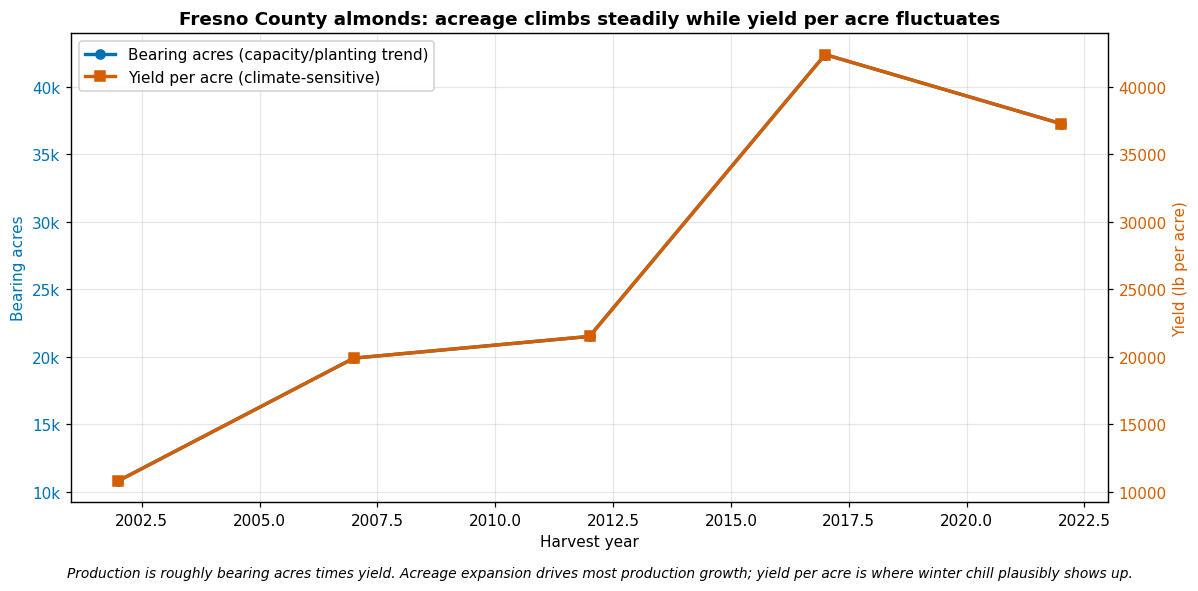

saved fig_acreage_vs_yield.png


In [14]:
fig, ax1 = plt.subplots(figsize=(11, 5.2))  # half-page width
yr = model_df.index.to_numpy()

l1, = ax1.plot(yr, model_df["BEARING_ACRES"], color=C_ACRE, marker="o",
               lw=2.2, label="Bearing acres (capacity/planting trend)")
ax1.set_xlabel("Harvest year")
ax1.set_ylabel("Bearing acres", color=C_ACRE)
ax1.tick_params(axis="y", labelcolor=C_ACRE)
ax1.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

ax2 = ax1.twinx()
ax2.grid(False)
l2, = ax2.plot(yr, model_df["FRESNO_YIELD"], color=C_YIELD, marker="s",
               lw=2.2, label="Yield per acre (climate-sensitive)")
ax2.set_ylabel("Yield (lb per acre)", color=C_YIELD)
ax2.tick_params(axis="y", labelcolor=C_YIELD)

ax1.set_title(TAG + "Fresno County almonds: acreage climbs steadily while yield "
              "per acre fluctuates", fontsize=12, fontweight="bold")
ax1.legend(handles=[l1, l2], loc="upper left", framealpha=0.9)
fig.text(0.5, -0.02,
         "Production is roughly bearing acres times yield. Acreage expansion drives "
         "most production growth; yield per acre is where winter chill plausibly shows up.",
         ha="center", fontsize=9, style="italic")
fig.tight_layout()
fig.savefig("fig_acreage_vs_yield.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig_acreage_vs_yield.png")

### 5b. Chill hours versus yield, the climate-effect plot (quarter-page)

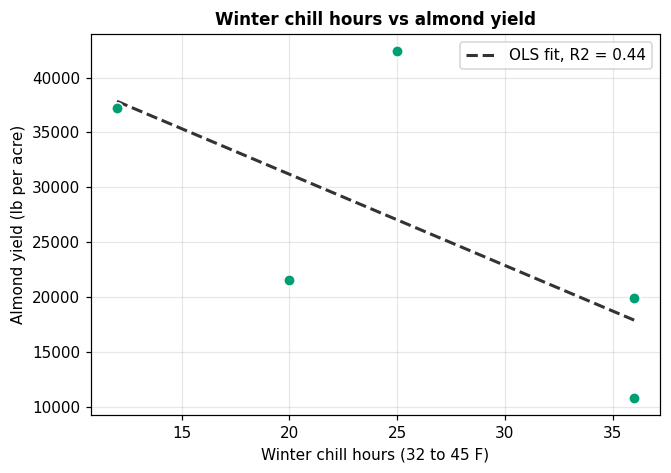

saved fig_chill_vs_yield.png


In [15]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))
x = model_df["CHILL_HOURS"].astype(float)
ax.scatter(x, y, color=C_CHILL, s=55, edgecolor="white", zorder=3)
# regression line from the single-feature fit
xs = np.linspace(x.min(), x.max(), 100)
res = single_results["CHILL_HOURS"]
ys = res.params["const"] + res.params["CHILL_HOURS"] * xs
ax.plot(xs, ys, color=C_FIT, lw=2, ls="--",
        label=f"OLS fit, R2 = {res.rsquared:.2f}")
ax.set_xlabel("Winter chill hours (32 to 45 F)")
ax.set_ylabel("Almond yield (lb per acre)")
ax.set_title(TAG + "Winter chill hours vs almond yield", fontsize=11, fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig("fig_chill_vs_yield.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig_chill_vs_yield.png")

### 5c. Yield over harvest year, with trend (quarter-page)

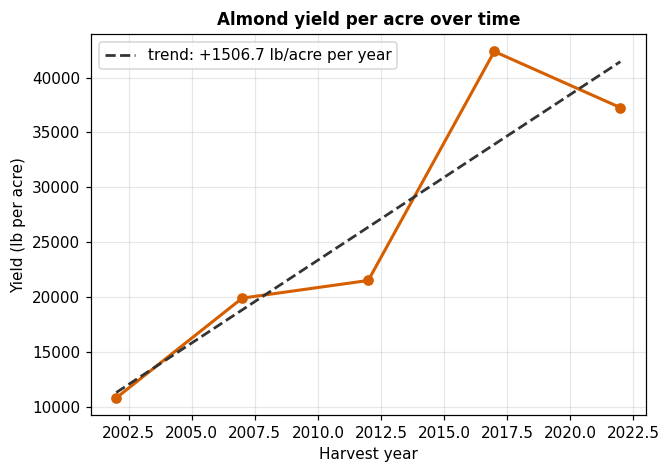

saved fig_yield_over_time.png


In [16]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(yr, model_df["FRESNO_YIELD"], color=C_YIELD, marker="o", lw=2)
# simple linear trend over time
coef = np.polyfit(yr.astype(float), model_df["FRESNO_YIELD"].astype(float), 1)
ax.plot(yr, np.polyval(coef, yr.astype(float)), color=C_FIT, ls="--", lw=1.8,
        label=f"trend: {coef[0]:+.1f} lb/acre per year")
ax.set_xlabel("Harvest year")
ax.set_ylabel("Yield (lb per acre)")
ax.set_title(TAG + "Almond yield per acre over time", fontsize=11, fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig("fig_yield_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig_yield_over_time.png")

### 5d. Single-feature explanatory power, coefficient of determination by feature (quarter-page)

One more supporting figure: a bar chart of the single-feature R-squared for each candidate, so the reader can see at a glance which temperature aspect carries the most signal. This is the visual companion to the precision question.

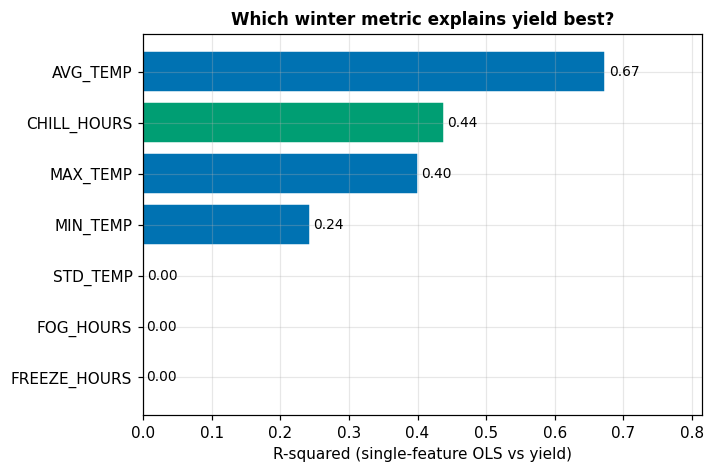

saved fig_feature_r2.png


In [17]:
fig, ax = plt.subplots(figsize=(6.6, 4.4))
r2s = {f: single_results[f].rsquared for f in FEATURES}
order = sorted(r2s, key=r2s.get)
vals = [r2s[f] for f in order]
colors = [C_CHILL if f == "CHILL_HOURS" else C_ACRE for f in order]
ax.barh(order, vals, color=colors, edgecolor="white")
for i, v in enumerate(vals):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("R-squared (single-feature OLS vs yield)")
ax.set_title(TAG + "Which winter metric explains yield best?", fontsize=11, fontweight="bold")
ax.set_xlim(0, max(vals) * 1.18 + 0.02)
fig.tight_layout()
fig.savefig("fig_feature_r2.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved fig_feature_r2.png")

**Reading the figures.** The relational figure is the one I want the reader to sit with. It makes the confound visible: acreage marches upward almost monotonically, so any model aimed at acreage or raw production would mostly be re-describing planting decisions. Yield per acre, on the other hand, wobbles year to year, and that wobble is where a weather signal can live. The chill versus yield scatter and the feature R-squared bar then show whether that wobble actually lines up with accumulated chill, and the yield-over-time plot puts the two-decade drift in context.

## Section 7. Recommendations and Ethical Considerations

The prose below is written so it can be lifted into the paper. The specific numbers referenced here are printed live in Section 8, so I keep this section qualitative and let the findings cell carry the figures.

### Recommendations

1. **Treat winter chill as an early, low-cost screening signal, not a forecast.** For a supply-chain planner or a lender, the value here is directional. When a Fresno winter accumulates unusually few chill hours, that is a reason to widen the range of expected yield outcomes and to ask growers and field agronomists for corroboration, not a reason to publish a point estimate of the harvest. The sample behind this analysis is small, so the responsible use is triage and attention-setting.

2. **Model yield per acre, never raw acreage or raw production, when the question is about weather.** Bearing acres rise for planting and economic reasons that have nothing to do with a given winter. Any stakeholder using this work should insist that climate-sensitivity claims be made against yield per acre, because that is the only target where the acreage expansion trend has been normalized out. This is the single most important methodological takeaway of my pass.

3. **Invest in denser, contiguous data before trusting any predictive claim.** The strongest next step is a continuous run of years with complete hourly coverage from the same station, so the relationship can be tested out of sample rather than described in a handful of points. Until then, pair the chill signal with independent indicators such as bloom-timing reports and soil moisture rather than acting on chill alone.

### Ethical considerations

**1. Who could be impacted by this analysis, positively or negatively?** Growers, farm labor, distributors, lenders, insurers, and ultimately consumers all sit downstream of an almond yield signal. Used carefully, an early chill signal could help smaller growers and buyers plan for a lean year that larger players might otherwise anticipate first, which is a mild equalizing effect. Used carelessly, the same signal could move prices or credit decisions against growers before a harvest is actually known, and the people with the least financial cushion, seasonal labor and small operations, would absorb that harm first. The asymmetry of who benefits and who is exposed is the core ethical fact here.

**2. What assumptions are we making about the data, and how could those introduce bias or ethical risk?** Three assumptions deserve to be named. First, yield is derived as production divided by bearing acres rather than measured directly, so any error or reporting lag in either USDA series propagates straight into the target, and derived yield can look precise while resting on two noisy inputs. Second, bearing acres carry a strong expansion trend that is entangled with time and with everything else that changed across two decades, so treating acreage-adjusted yield as a clean climate response still leaves confounds we cannot fully separate. Third, and most important, the framing assumes cold more or less directly causes yield, when growers actively manage dormancy and bloom, they can mist, cool, adjust varieties, and irrigate, so part of any measured relationship reflects human response to weather, not weather alone. Presenting the result as if nature acts on a passive orchard would overstate the determinism and could bias decisions against growers who are in fact adapting.

**3. How was the data sourced, and were privacy, consent, or ownership issues relevant?** Both sources are public. Almond acreage and production come from USDA NASS Quick Stats, and the hourly weather comes from NOAA Local Climatological Data for a public Fresno station. These are aggregate, government-published series with no individual persons in them, so privacy and consent are not directly at stake. The honest caveat is about ownership and interpretation rather than consent: county-level aggregates can still reflect a small number of large operations, so even public aggregate data should not be used to reason about any single named grower.

**4. How might results be misinterpreted, overgeneralized, or misused?** The most likely misreads are treating a correlation from a handful of years as a forecast, generalizing a Fresno County result to other counties or crops, and reading the chill coefficient as a lever, as if adding chill hours would mechanically add pounds. A number pulled out of this notebook and placed in a pricing model without its sample size and its caveats would be misuse. The small n and the descriptive, correlational framing must travel with any number we report.

**5. What responsibility does the team have if the analysis drives a harmful or unintended decision?** We are responsible for making the limits as legible as the result. That means reporting n prominently, labeling yield as derived, flagging the acreage confound, and refusing to present this as a forecasting model when it is not one. If a stakeholder used our work to justify a decision that harmed growers or workers, the ethical failure would partly be ours if we had dressed a small descriptive study up as a predictive one. Our duty is to hand over the uncertainty intact, and to say clearly what the analysis cannot support.

## Section 8. Findings summary

The bullets below are generated from the live model output so they always match whatever data is loaded. On synthetic data they carry the placeholder tag. Paste the real-data version into the Results section of the paper.

In [18]:
best_slope = best_res.params[best_feat]
best_p = best_res.pvalues[best_feat]
sign = "positive" if best_slope > 0 else "negative"
multi_row = [m for m in ModelPerformance._registry if m.name.startswith("Multiple")][0]

print(TAG + "FINDINGS SUMMARY (headline numbers for the Results section)")
print("=" * 66)
print(f"* Sample size: n = {N} harvest years "
      f"({model_df.index.min()} to {model_df.index.max()}).")
print(f"* Target: FRESNO_YIELD ({TARGET_PATH[0]} path), lb per acre.")
print(f"* Strongest single predictor of yield: {best_feat}.")
print(f"    - coefficient sign: {sign} (slope = {best_slope:.4f} lb/acre per unit)")
print(f"    - single-feature R-squared = {best_res.rsquared:.3f}, p = {best_p:.4f}")
if "CHILL_HOURS" in single_results and "AVG_TEMP" in single_results:
    cr = single_results["CHILL_HOURS"].rsquared
    ar = single_results["AVG_TEMP"].rsquared
    print(f"* Chill hours R2 = {cr:.3f} vs avg winter temp R2 = {ar:.3f} "
          f"-> chill {'wins' if cr > ar else 'does not win'}.")
print(f"* Multiple regression: R2 = {multi_row.r2:.3f}, "
      f"adj R2 = {multi_row.adj_r2:.3f}, RMSE = {multi_row.rmse:.1f} lb/acre.")
print(f"* Framing: directional/correlational evidence given small n, not a forecast.")
print("=" * 66)
if USING_SYNTHETIC:
    print("\nNOTE: these are SYNTHETIC placeholder numbers. Replace the four raw")
    print("files with the real USDA/NOAA pulls and re-run before quoting anything.")

FINDINGS SUMMARY (headline numbers for the Results section)
* Sample size: n = 5 harvest years (2002 to 2022).
* Target: FRESNO_YIELD (acres_only path), lb per acre.
* Strongest single predictor of yield: AVG_TEMP.
    - coefficient sign: positive (slope = 9039.5217 lb/acre per unit)
    - single-feature R-squared = 0.674, p = 0.0885
* Chill hours R2 = 0.438 vs avg winter temp R2 = 0.674 -> chill does not win.
* Multiple regression: R2 = 0.675, adj R2 = 0.350, RMSE = 6655.4 lb/acre.
* Framing: directional/correlational evidence given small n, not a forecast.


### Reproducibility note

This notebook runs restart-and-run-all clean top to bottom. It reads the four raw files if they are present and otherwise generates a labeled synthetic stand in so the pipeline, the figures, and the metrics all execute. To finalize for submission, place `raw_data_USDA.csv`, `raw_temp_part1.csv`, `raw_temp_part2.csv`, and `raw_temp_part3.csv` in this folder, choose Restart and Run All, confirm the banner reports real data, and re-take the screenshots. I kept everything in this single notebook rather than splitting it into scripts, and I chose chill hours rather than a Dynamic Model chill-portions metric because chill hours is defensible for this scope and the data can support it honestly.